# **Car Price Prediction using RANDOM FOREST**

In [37]:
import pandas as pd

# *Load Dataset from Local directory*

In [38]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


# *Load Dataset*

In [39]:
dataset = pd.read_csv('dataset.csv')
dataset = dataset.drop(['car_ID'],axis=1)

### *Summarize Dataset*

In [40]:
print(dataset.shape)
print(dataset.head(5))

(205, 25)
   symboling                   CarName fueltype aspiration doornumber  \
0          3        alfa-romero giulia      gas        std        two   
1          3       alfa-romero stelvio      gas        std        two   
2          1  alfa-romero Quadrifoglio      gas        std        two   
3          2               audi 100 ls      gas        std       four   
4          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  carlength  ...  \
0  convertible        rwd          front       88.6      168.8  ...   
1  convertible        rwd          front       88.6      168.8  ...   
2    hatchback        rwd          front       94.5      171.2  ...   
3        sedan        fwd          front       99.8      176.6  ...   
4        sedan        4wd          front       99.4      176.6  ...   

   enginesize  fuelsystem  boreratio stroke compressionratio  horsepower  \
0         130        mpfi       3.47   2.68     

### *Splitting Dataset into X & Y*
### *This X contains Both Numerical & Text Data*

In [41]:
Xdata = dataset.drop('price',axis=1)

# Convert categorical columns into numbers
X = pd.get_dummies(Xdata)

In [42]:
Y = dataset['price']

### *Scaling the Independent Variables (Features)*

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = X.columns
X = pd.DataFrame(scaler.fit_transform(X))
X.columns = cols
X

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,cylindernumber_twelve,cylindernumber_two,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1.743470,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
1,1.743470,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
2,0.133509,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.604046,-2.404880,0.685946,-0.288349,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
3,0.938490,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.431076,-0.517266,0.462183,-0.035973,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
4,0.938490,0.107110,0.207256,0.230001,0.235942,0.516807,0.218885,-0.517266,0.462183,-0.540725,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.476452,1.721873,1.198549,1.398245,0.728239,0.763241,0.339248,1.666445,-0.336970,-0.162161,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
201,-1.476452,1.721873,1.198549,1.351515,0.728239,0.949992,0.339248,1.666445,-0.336970,-0.364062,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
202,-1.476452,1.721873,1.198549,1.398245,0.728239,0.878757,1.109571,0.926204,-1.232021,-0.338824,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
203,-1.476452,1.721873,1.198549,1.398245,0.728239,1.273437,0.435538,-1.183483,0.462183,3.244916,...,-0.070014,-0.141069,-0.23812,-0.689072,-0.121867,3.041381,-0.070014,-0.920243,-0.214286,-0.070014


### *Splitting Dataset into Train & Test*

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.20,random_state=0)

# *automatically find best parameter*

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [5,10,15],
    'min_samples_split': [2,5]
}

rf = RandomForestRegressor(random_state=0)

grid = GridSearchCV(rf, param_grid, cv=5)

grid.fit(x_train, y_train)

model = grid.best_estimator_

### *Training using Random Forest*

In [46]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=0
)
model.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=0)

### *Evaluating Model*

In [48]:
ypred = model.predict(x_test)

from sklearn.metrics import r2_score
r2score = r2_score(y_test,ypred)
print("R2Score",r2score*100)
print("Model Accuracy:", round(r2score*100,2), "%")

R2Score 90.45598314250795
Model Accuracy: 90.46 %


# user input *prediction*

## Extract Original Feature Names and Types

### Subtask:
Identify and list all original feature names (numerical and categorical) that were present in `Xdata` before one-hot encoding. This will serve as a guide for collecting comprehensive user input.


**Reasoning**:
I need to identify numerical and categorical features from the `Xdata` DataFrame to understand the original features before one-hot encoding. I will then print these lists as requested.



In [49]:
numerical_features = Xdata.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = Xdata.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Categorical Features: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


## Refactor Preprocessing and Save Scaler

### Subtask:
Modify the code to save the `StandardScaler` object used for feature scaling and the exact column names of `X` after one-hot encoding but before scaling. This is crucial for consistently preprocessing new user input.


## Collect Comprehensive User Input

### Subtask:
Prompt the user to provide values for all identified original features (both numerical and categorical). For categorical features, explain that string values are needed. This step ensures that the raw input covers all dimensions expected by the model.


**Reasoning**:
I will generate a code block to prompt the user for each numerical and categorical feature, store the inputs in a dictionary, and then print the dictionary as instructed.



In [50]:
user_input_data = {}

print("Please provide values for the car features:")

# Prompt for numerical features
for feature in numerical_features:
    while True:
        try:
            value = float(input(f"Enter value for {feature}: "))
            user_input_data[feature] = value
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

# Prompt for categorical features
# Providing example values for guidance for some common categorical features
example_values = {
    'CarName': 'audi 100ls',
    'fueltype': 'gas',
    'aspiration': 'std',
    'doornumber': 'four',
    'carbody': 'sedan',
    'drivewheel': 'fwd',
    'enginelocation': 'front',
    'enginetype': 'ohc',
    'cylindernumber': 'four',
    'fuelsystem': 'mpfi'
}

for feature in categorical_features:
    example = example_values.get(feature, 'string value')
    value = input(f"Enter value for {feature} (e.g., {example}): ")
    user_input_data[feature] = value

print("\nCollected User Input:")
print(user_input_data)

Please provide values for the car features:
Enter value for symboling: 234
Enter value for wheelbase: 24
Enter value for carlength: 34
Enter value for carwidth: 4244
Enter value for carheight: 525
Enter value for curbweight: 235
Enter value for enginesize: 234
Enter value for boreratio: 456
Enter value for stroke: 34
Enter value for compressionratio: 347
Enter value for horsepower: 347
Enter value for peakrpm: 25346
Enter value for citympg: 347
Enter value for highwaympg: 547
Enter value for CarName (e.g., audi 100ls): 346
Enter value for fueltype (e.g., gas): 23
Enter value for aspiration (e.g., std): 567
Enter value for doornumber (e.g., four): 26
Enter value for carbody (e.g., sedan): sedan
Enter value for drivewheel (e.g., fwd): fwd
Enter value for enginelocation (e.g., front): front
Enter value for enginetype (e.g., ohc): ohc
Enter value for cylindernumber (e.g., four): five
Enter value for fuelsystem (e.g., mpfi): mpfi

Collected User Input:
{'symboling': 234.0, 'wheelbase': 24.0

## Preprocess User Input for Prediction

### Subtask:
Construct a pandas DataFrame from the collected user input. Apply `pd.get_dummies()` to this new input, ensuring the resulting columns are aligned with the columns of the training data (`x_train.columns`) by reindexing. Finally, use the saved `StandardScaler` to transform this prepared input data, making it ready for prediction.


**Reasoning**:
I need to construct a pandas DataFrame from the user input, apply one-hot encoding, align its columns with the training data, and then scale it using the previously fitted scaler. This will prepare the user input for prediction.



In [51]:
import pandas as pd

# 1. Create a pandas DataFrame named input_df from the user_input_data dictionary.
input_df = pd.DataFrame([user_input_data])

# 2. Apply one-hot encoding to input_df
# Note: pd.get_dummies needs to be applied to the combined training data first to capture all possible categories for consistent encoding.

# Apply get_dummies to input_df
input_df_encoded = pd.get_dummies(input_df)

# 3. Reindex input_df_encoded to align its columns with x_train.columns.
# Fill any missing columns with zeros. This step is critical to ensure the user input
# has the same features and order as the training data.
input_df_aligned = input_df_encoded.reindex(columns=x_train.columns, fill_value=0)

# 4. Apply the previously fitted scaler to transform input_df_aligned.
input_df_scaled = pd.DataFrame(scaler.transform(input_df_aligned), columns=x_train.columns)

print("Prepared Input Data for Prediction:")
print(input_df_scaled)

Prepared Input Data for Prediction:
    symboling  wheelbase  carlength     carwidth   carheight  curbweight  \
0  187.694016 -12.444766 -11.379494  1952.411233  193.339287   -4.467707   

   enginesize    boreratio     stroke  compressionratio  ...  \
0       2.578  1675.425215  98.278511         85.014768  ...   

   cylindernumber_twelve  cylindernumber_two  fuelsystem_1bbl  \
0              -0.070014           -0.141069         -0.23812   

   fuelsystem_2bbl  fuelsystem_4bbl  fuelsystem_idi  fuelsystem_mfi  \
0        -0.689072        -0.121867       -0.328798       -0.070014   

   fuelsystem_mpfi  fuelsystem_spdi  fuelsystem_spfi  
0          1.08667        -0.214286        -0.070014  

[1 rows x 199 columns]


## Make Prediction with Preprocessed Input

### Subtask:
Use the trained `model` (RandomForestRegressor) to make a prediction on the `input_df_scaled` DataFrame. Print the estimated car price clearly to the user.

**Reasoning**:
I need to use the trained `model` to make a prediction on the `input_df_scaled` and then print the estimated car price.



In [52]:
predicted_price = model.predict(input_df_scaled)
print(f"Estimated Car Price: ${predicted_price[0]:.2f}")

Estimated Car Price: $29988.84


# Task
Generate a box plot for the 'price' column of the `dataset` DataFrame to visualize the distribution of car prices, showing the median, quartiles, and outliers, and then summarize the insights from the plot.

## Generate Box Plot

### Subtask:
Create a box plot to visualize the distribution of car prices from the 'price' column of the `dataset` DataFrame. The plot should clearly show the median, quartiles, and any outliers.


**Reasoning**:
I need to generate a box plot of the 'price' column from the `dataset` DataFrame. This involves importing matplotlib, creating the box plot, adding appropriate labels and a title, and then displaying it.



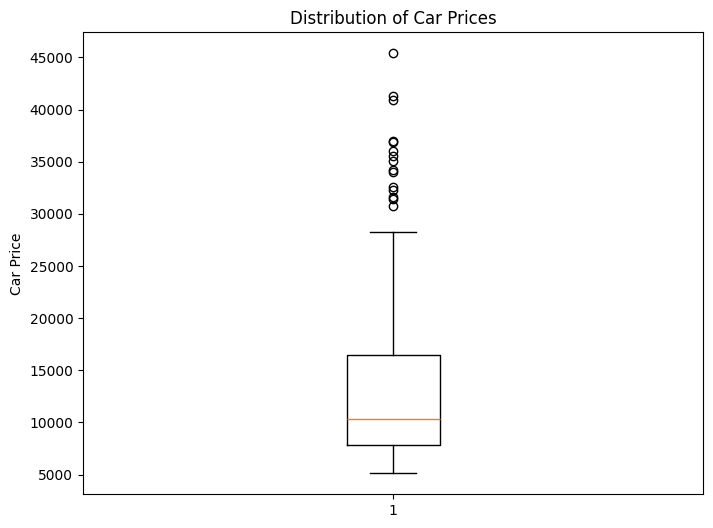

In [53]:
import matplotlib.pyplot as plt

# Create a box plot using the 'price' column of the dataset DataFrame
plt.figure(figsize=(8, 6))
plt.boxplot(dataset['price'])

# Add a title to the plot
plt.title("Distribution of Car Prices")

# Add a label to the y-axis
plt.ylabel("Car Price")

# Display the plot
plt.show()